# 1 - Carga y Configuracion

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/dataset_f1_estandarizado.csv")

# 2 - Aplicar PCA

In [68]:
# Aplicar PCA con todos los componentes posibles
pca = PCA()
pca.fit(df)

PCA()

# 3 - Busqueda de cantidad de PC

Autovalores de los Componentes Principales:
PC1: 7.2609
PC2: 1.4004
PC3: 0.6091
PC4: 0.4608
PC5: 0.3635
PC6: 0.2595
PC7: 0.0509


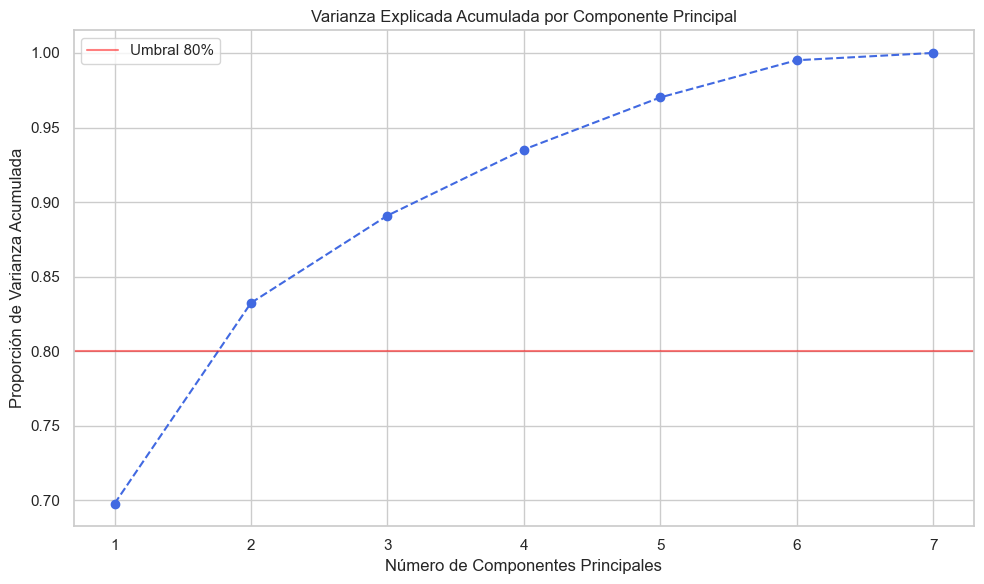

In [69]:
autovalores = pca.explained_variance_
varianza_acumulada = pca.explained_variance_ratio_.cumsum()

print("Autovalores de los Componentes Principales:")
for i, autovalor in enumerate(autovalores):
    print(f"PC{i + 1}: {autovalor:.4f}")

# 1. Gráfico de Varianza Acumulada
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o",
    linestyle="--",
    color="royalblue",
)
plt.axhline(y=0.80, color="red", linestyle="-", alpha=0.5, label="Umbral 80%")
plt.title("Varianza Explicada Acumulada por Componente Principal")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Proporción de Varianza Acumulada")

if len(varianza_acumulada) <= 20:
    plt.xticks(range(1, len(varianza_acumulada) + 1))

plt.legend()
plt.tight_layout()
plt.show()

# 4 - Analisis de las 3 PC seleccionadas

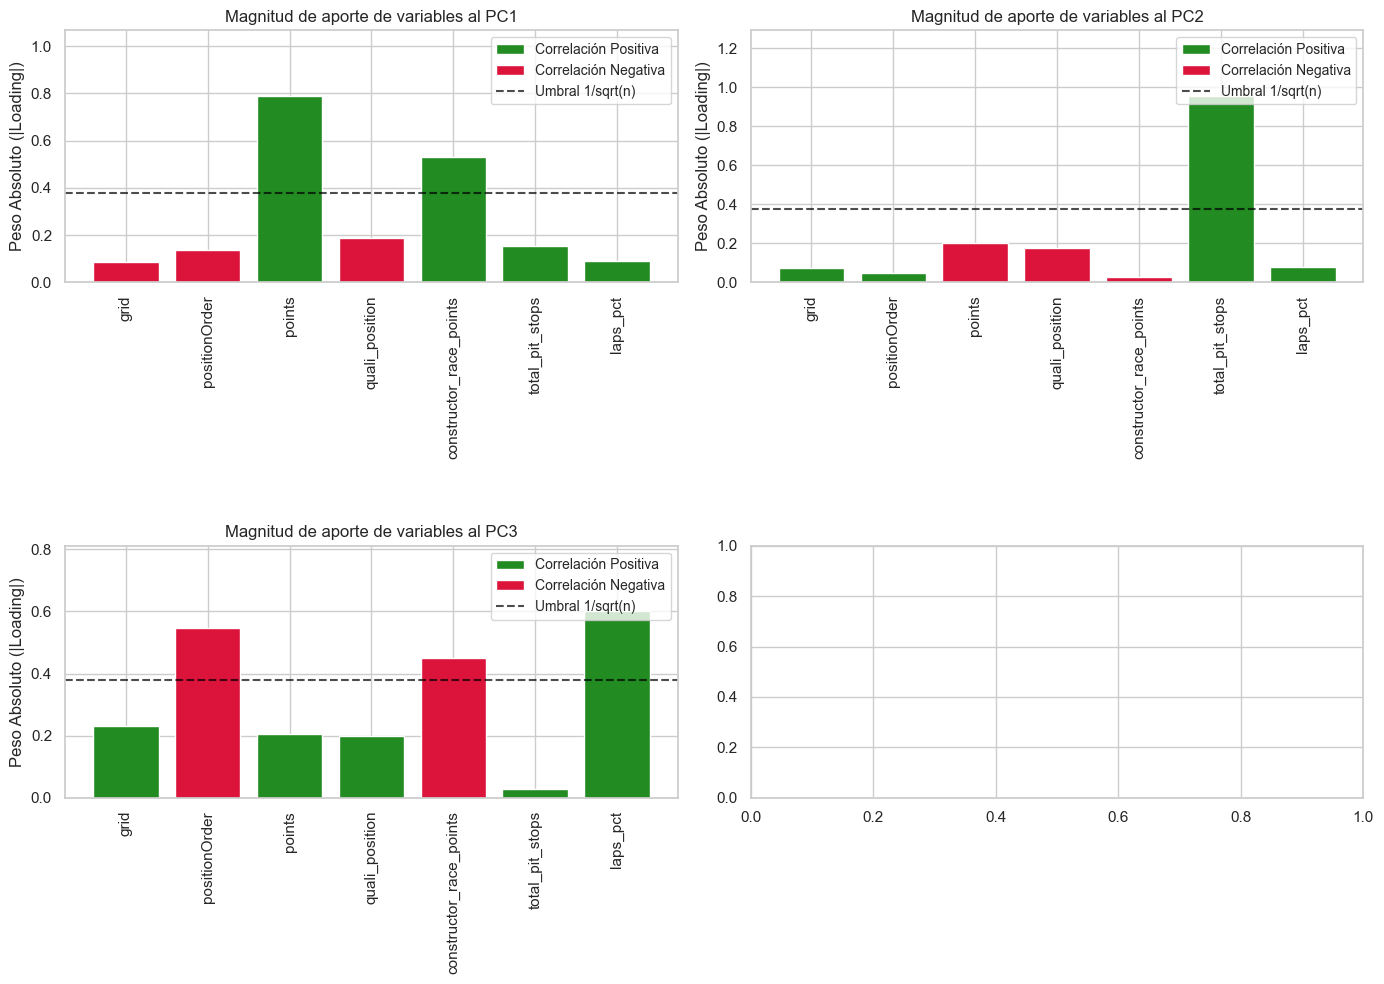

In [70]:
# 2. Gráficos de aportes (Magnitud absoluta) para las primeras 4 componentes
n_components_to_plot = min(3, pca.n_components_)
componentes = pca.components_[:n_components_to_plot]
columnas = df.columns

# Calcular el umbral (1 / raíz cuadrada de n)
n_variables = len(columnas)
umbral = 1 / (n_variables**0.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_components_to_plot):
    cargas_absolutas = np.abs(componentes[i])
    colores = ["forestgreen" if carga >= 0 else "crimson" for carga in componentes[i]]

    axes[i].bar(columnas, cargas_absolutas, color=colores)

    altura_maxima = max(cargas_absolutas)
    axes[i].set_ylim(0, altura_maxima * 1.35)

    axes[i].set_title(f"Magnitud de aporte de variables al PC{i + 1}")
    axes[i].set_ylabel("Peso Absoluto (|Loading|)")
    axes[i].tick_params(axis="x", rotation=90)

    linea_umbral = axes[i].axhline(
        y=umbral, color="black", linestyle="--", alpha=0.7, label="Umbral 1/sqrt(n)"
    )

    elementos_leyenda = [
        Patch(facecolor="forestgreen", label="Correlación Positiva"),
        Patch(facecolor="crimson", label="Correlación Negativa"),
        linea_umbral,
    ]
    axes[i].legend(handles=elementos_leyenda, loc="upper right", fontsize="small")

plt.tight_layout(h_pad=4.0)
plt.show()

### Interpretacion de cada PC

#### PC1 = Rendimiento General y Exito en el Campeonato

Esta componente captura la sinergia entre el éxito de la carrera actual y el éxito general de la temporada. Un valor alto en esta componente representa a un piloto y escudería que no solo están dominando el campeonato (muchos puntos y victorias en la temporada), sino que también tuvieron un excelente desempeño en esa carrera específica (sumando muchos puntos para el piloto y el equipo).

#### PC2 = Anomalías de los Favoritos (Temporada vs. Carrera)

Esta componente captura el subrendimiento o mala suerte de los equipos principales. Contrapone fuertemente ser un equipo/piloto ganador en la temporada con no sumar puntos en la carrera actual. Un valor alto aquí indicaría una carrera donde los favoritos del campeonato (con muchas victorias en el año) tuvieron un pésimo resultado en esa fecha específica, probablemente debido a abandonos (DNFs), choques o fallos mecánicos graves.

#### PC3 = Caos en Carrera y Frecuencia de Paradas

Esta componente puede interpretarse como "Carreras Accidentadas o Estrategias Fallidas". Destaca situaciones donde hubo una alta cantidad de paradas en boxes que correlacionan con una baja cosecha de puntos en esa carrera. Además, contrapone a pilotos que tienen buenos puntos en la temporada, pero cuyas escuderías no son las más dominantes en victorias. Refleja el impacto negativo de una carrera caótica (múltiples paradas por clima, roturas o incidentes) en la suma de puntos.

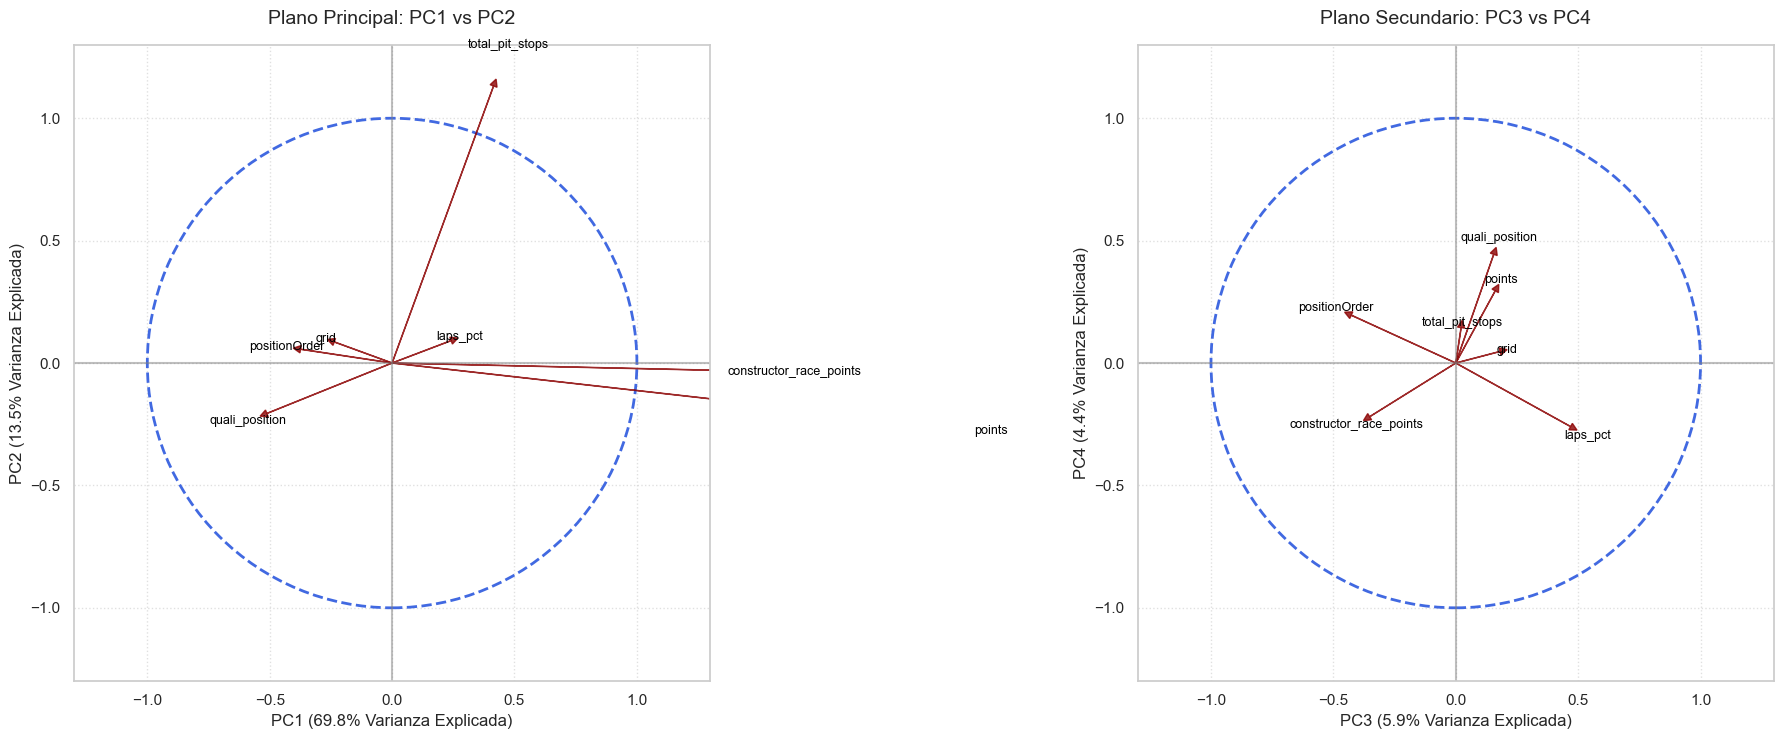

In [71]:
# 3. CÍRCULO DE CORRELACIONES

correlaciones_pc1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
correlaciones_pc2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])
correlaciones_pc3 = pca.components_[2] * np.sqrt(pca.explained_variance_[2])
correlaciones_pc4 = pca.components_[3] * np.sqrt(pca.explained_variance_[3])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))


def dibujar_circulo_correlacion(ax, corr_x, corr_y, pc_x_idx, pc_y_idx):
    circulo = plt.Circle(
        (0, 0), 1, color="royalblue", fill=False, linestyle="--", linewidth=2
    )
    ax.add_patch(circulo)

    for i, var in enumerate(columnas):
        ax.arrow(
            0,
            0,
            corr_x[i],
            corr_y[i],
            color="darkred",
            alpha=0.8,
            head_width=0.03,
            head_length=0.03,
        )
        ax.text(
            corr_x[i] * 1.15,
            corr_y[i] * 1.15,
            var,
            color="black",
            ha="center",
            va="center",
            fontsize=9,
        )

    ax.axhline(0, color="gray", linestyle="-", alpha=0.5)
    ax.axvline(0, color="gray", linestyle="-", alpha=0.5)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", alpha=0.6)

    var_x = pca.explained_variance_ratio_[pc_x_idx] * 100
    var_y = pca.explained_variance_ratio_[pc_y_idx] * 100
    ax.set_xlabel(f"PC{pc_x_idx + 1} ({var_x:.1f}% Varianza Explicada)", fontsize=12)
    ax.set_ylabel(f"PC{pc_y_idx + 1} ({var_y:.1f}% Varianza Explicada)", fontsize=12)


# Dibujar el primer panel (PC1 vs PC2)
dibujar_circulo_correlacion(ax1, correlaciones_pc1, correlaciones_pc2, 0, 1)
ax1.set_title("Plano Principal: PC1 vs PC2", fontsize=14, pad=15)

# Dibujar el segundo panel (PC3 vs PC4)
dibujar_circulo_correlacion(ax2, correlaciones_pc3, correlaciones_pc4, 2, 3)
ax2.set_title("Plano Secundario: PC3 vs PC4", fontsize=14, pad=15)

plt.tight_layout(w_pad=4.0)
plt.show()

# 5 - Guardado del dataset PCA

In [72]:
# Transformar los datos estandarizados al nuevo espacio de componentes principales
df_transformado = pca.transform(df)

# Extraer solo las primeras 4 columnas (PC1 a PC4)
df_pca = pd.DataFrame(df_transformado[:, :2], columns=["PC1", "PC2"])

# Guardar el resultado en la carpeta data
ruta_salida = "data/dataset_f1_pca.csv"
df_pca.to_csv(ruta_salida, index=False)

print(
    f"\nProceso finalizado. Dataset reducido a 4 componentes guardado en: '{ruta_salida}'"
)
print(f"Dimensiones del nuevo dataset: {df_pca.shape}")


Proceso finalizado. Dataset reducido a 4 componentes guardado en: 'data/dataset_f1_pca.csv'
Dimensiones del nuevo dataset: (26759, 2)
